# **Stroke: EDA, UMAP & Resampling**

**Hello and welcome**.  

**This is part 2 to a 3-kernel project on Stroke Prediction.**

  
**Part 1 is Preprocessing: Data Cleaning, Target Encoding and MICE for missing values**  
Link: **https://www.kaggle.com/mahmoudlimam/stroke-pre-processing-mice-target-encoding**

  
**Part 2 (which is this one) is EDA (including UMAP and PCA) and Random Oversampling**

  
**Part 3 is Detailed Feature extraction and Selection, and model evaluation**  
Link: **https://www.kaggle.com/mahmoudlimam/stroke-pca-ica-lda-kmeans-dbscan-prediction** 

I didn't include a hyperparameter tuning section as Feature Engineering in an F1_Score of 1 with a somewhat deep Random Forest.

بسم الله

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.style as stl
stl.use("ggplot")
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=10)
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("../input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")
data.drop("id",axis=1,inplace=True)

In [3]:
impdata = pd.read_csv("../input/imputed-stroke-dataset/impstroke.csv")
impdata.drop("Unnamed: 0",axis=1,inplace=True)
x=impdata.drop("stroke",axis=1)
y=impdata["stroke"]

This indicates imbalance in the target variable.

# Exploratory Analysis

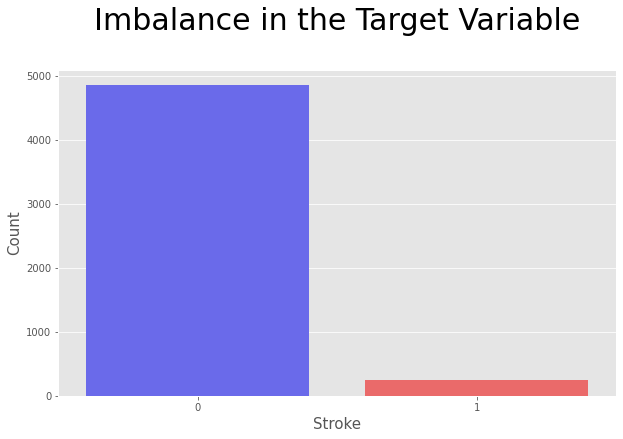

In [4]:
plt.figure(figsize=(10,6))
cp=sns.countplot(x=data["stroke"],palette="seismic")
plt.title("Imbalance in the Target Variable\n",fontsize=30)
plt.xlabel("Stroke",fontsize=15)
plt.ylabel("Count",fontsize=15)
plt.show()

SMOTE and its variants are common techniques for oversampling.  
Many of them are quite sensitive to outliers though.  
Let's make a quick EDA to search for outliers

In [5]:
continuous=["bmi","avg_glucose_level","age"] #work type is an encoded categorical feature, not a continuous one

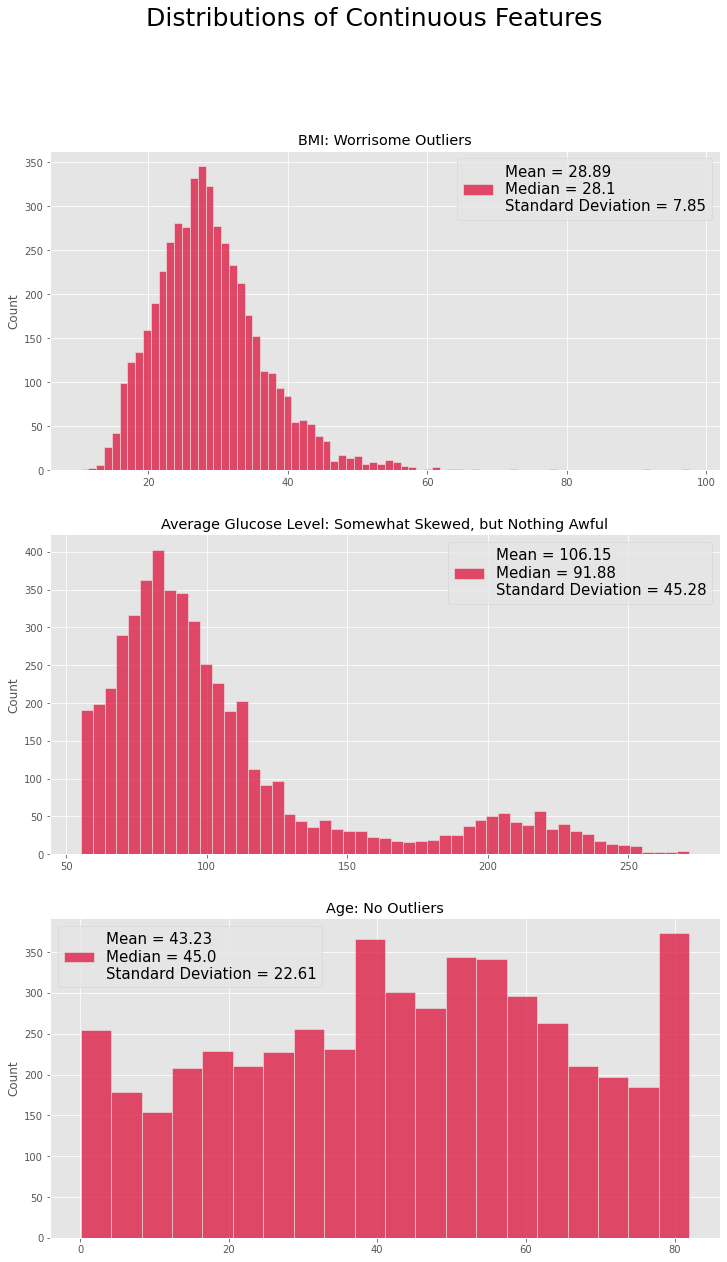

In [6]:
fig,axes=plt.subplots(nrows=3,ncols=1,figsize=(12,20))
fig.suptitle("Distributions of Continuous Features",fontsize=25)


label1='Mean = {}\nMedian = {}\nStandard Deviation = {}'.format("%.2f"%data["bmi"].mean(),
                                                               data["bmi"].median(),
                                                               "%.2f"%data["bmi"].std())
sns.histplot(x=data["bmi"],ax=axes[0],color='crimson',label=label1).legend(loc='best',fontsize=15)
axes[0].set_title("BMI: Worrisome Outliers")
axes[0].set_xlabel(None)


label2='Mean = {}\nMedian = {}\nStandard Deviation = {}'.format("%.2f"%data["avg_glucose_level"].mean(),
                                                                "%.2f"%data["avg_glucose_level"].median(),
                                                                "%.2f"%data["avg_glucose_level"].std())
sns.histplot(x=data["avg_glucose_level"],ax=axes[1],color="crimson", label=label2).legend(loc='best',fontsize=15)
axes[1].set_title("Average Glucose Level: Somewhat Skewed, but Nothing Awful")
axes[1].set_xlabel(None)


label3='Mean = {}\nMedian = {}\nStandard Deviation = {}'.format("%.2f"%data["age"].mean(),
                                                                data["age"].median(),
                                                                "%.2f"%data["age"].std())
sns.histplot(x=data["age"],ax=axes[2],color="crimson",label=label3).legend(loc='best',fontsize=15)
axes[2].set_title("Age: No Outliers")
axes[2].set_xlabel(None)

plt.show()

In [7]:
categoricals = []
for col in data.drop("stroke",axis=1):
    if not(col in continuous):
        categoricals.append(col)

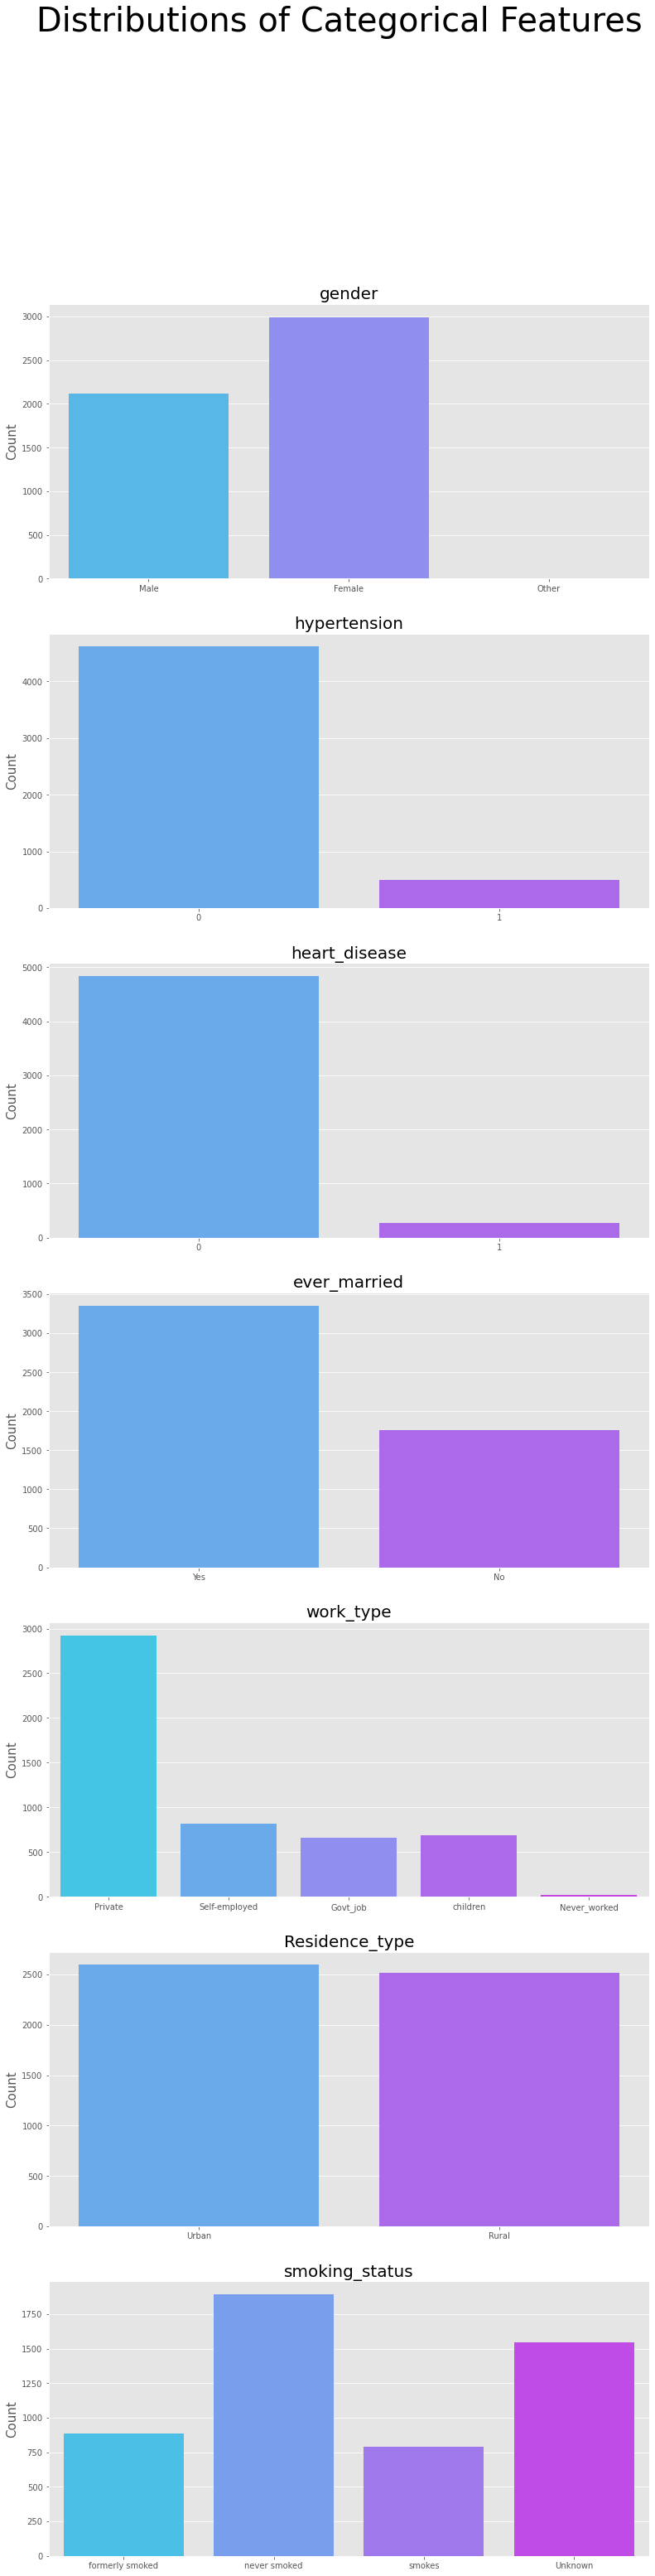

In [8]:
fig,axes=plt.subplots(nrows=7,ncols=1,figsize=(13,50))
fig.suptitle("Distributions of Categorical Features",fontsize=40)
i=0
for col in (data.drop("stroke",axis=1).columns):
    if not(col in continuous):
        sns.countplot(x=data[col],ax=axes[i],palette="cool")
        axes[i].set_title(col,fontsize=20)
        axes[i].set_xlabel(None)
        axes[i].set_ylabel("Count",fontsize=15)
        i+=1
plt.show()

In [9]:
for col in categoricals:
    impdata[col] = impdata[col].astype("category")

plt.figure(figsize=(20,15))
cat_mi = pd.DataFrame(np.zeros((7,7)),columns=categoricals,index=categoricals)
for i in range(7):
    for j in range(7):
        print(data.columns[i]+" vs "+data.columns[j])
        cat_mi.iloc[i,j] = mutual_info_classif(impdata[data.columns[i]].values.reshape(-1,1),impdata[data.columns[j]].values.reshape(-1,),random_state=11)
        print("finished")

In [10]:
from sklearn.preprocessing import RobustScaler
from umap import UMAP

In [11]:
rb=RobustScaler()
scaled_data = rb.fit_transform(x)

In [12]:
ump=UMAP(random_state=11,n_neighbors=5,min_dist=0.5)

In [13]:
umap_data = ump.fit_transform(scaled_data)

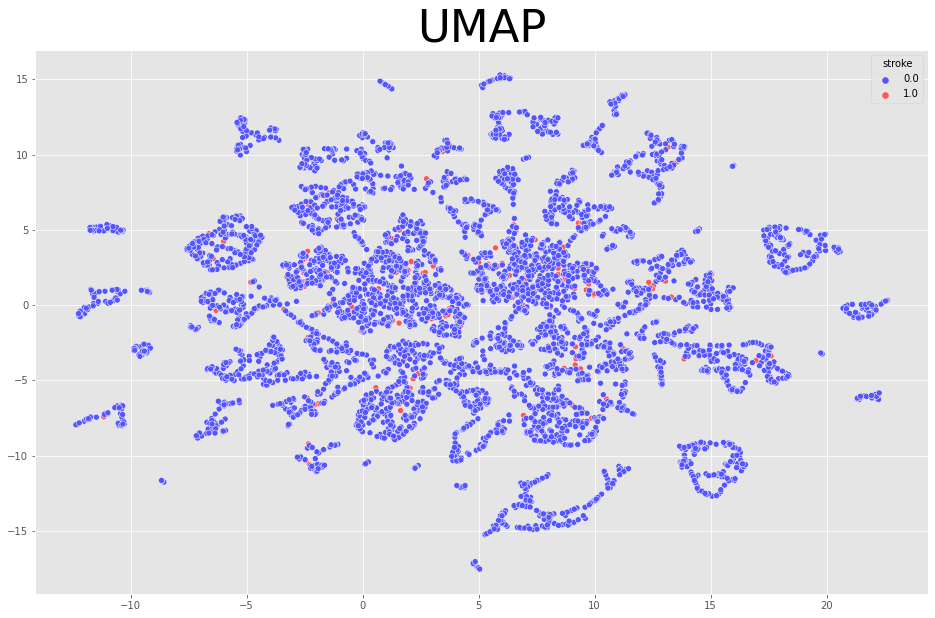

In [14]:
plt.figure(figsize=(16,10))
sns.scatterplot(x=umap_data[:,0],y=umap_data[:,1],hue=y,palette="seismic")
plt.title('UMAP',fontsize=45)
plt.show()

Patients in the "1" class don't seem to be well differentiated in one separate cluster.  

In [15]:
from sklearn.decomposition import PCA

In [16]:
pca = PCA(n_components=2)
pca_data=pca.fit_transform(scaled_data)

In [17]:
pca_data=pd.DataFrame(pca_data,columns=["PC1","PC2"])
pca_data["Stroke"]=y
pca_data.head()

,PC1,PC2,Stroke
0,-3.082465,3.484980,1.0
1,-42.014358,2.347247,1.0
2,-3.062125,0.190586,1.0
3,-3.070367,1.814124,1.0
4,-42.006356,1.517455,1.0


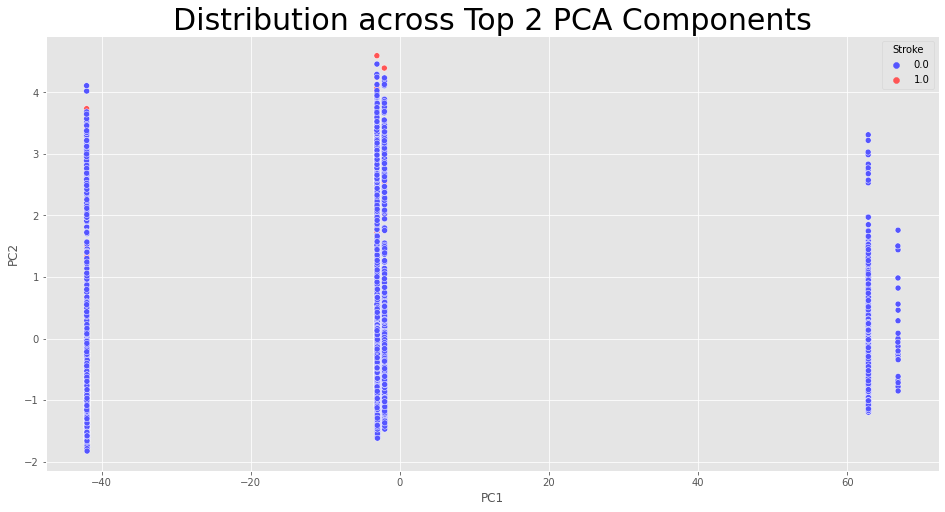

In [18]:
plt.figure(figsize=(16,8))
sns.scatterplot(x="PC1",y="PC2",hue="Stroke",data=pca_data, palette="seismic")
plt.title("Distribution across Top 2 PCA Components",fontsize=30)
plt.show()

This is very unusual.  
But these two would make nice features.  
We'll see about that in the feature engineering section.

# Random Sampling

## 1 - Random Oversampling

In [19]:
from imblearn.over_sampling import RandomOverSampler

In [20]:
proportions = [0.1,0.33,0.5,0.66,1]

In [21]:
oversampled_data = {}
for i in proportions:
    oversampler = RandomOverSampler(sampling_strategy=i)
    x_ros, y_ros = oversampler.fit_resample(x, y)
    x_ros = rb.fit_transform(x_ros)
    oversampled_data[i] = [x_ros,y_ros]

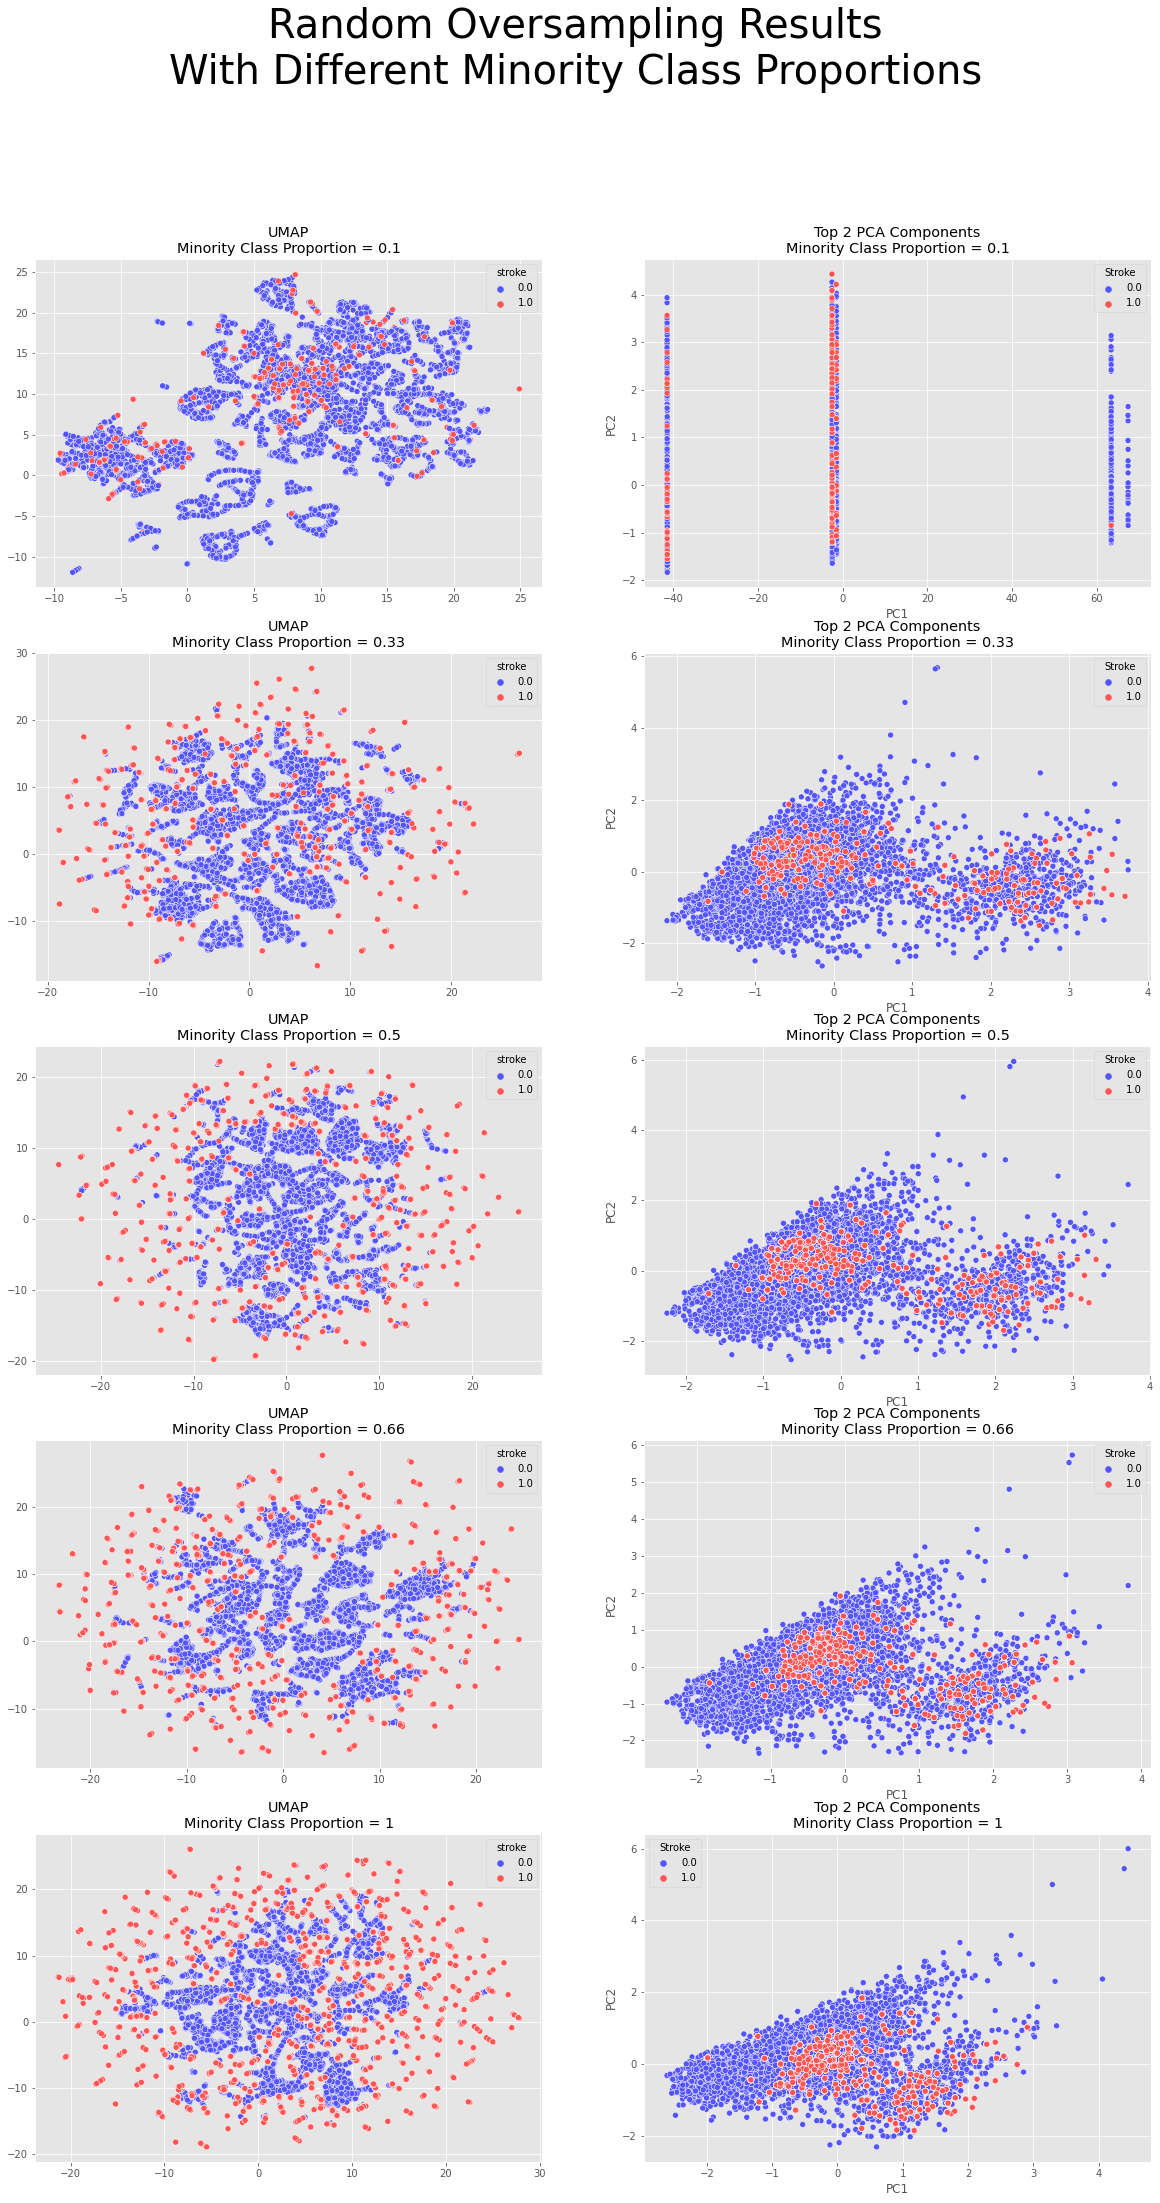

In [22]:
fig,axes=plt.subplots(nrows=5,ncols=2,figsize=(20,35))
fig.suptitle("Random Oversampling Results\nWith Different Minority Class Proportions",fontsize=40)
for i in range(5):
    proportion = proportions[i]
    x_ros, y_ros = oversampled_data[proportion]
    ros_umap = ump.fit_transform(x_ros)
    sns.scatterplot(x=ros_umap[:,0],y=ros_umap[:,1],hue=y_ros,palette="seismic",ax=axes[i,0])
    axes[i,0].set_title(f"UMAP\nMinority Class Proportion = {proportion}")
    pca_ros=pca.fit_transform(x_ros)
    pca_ros=pd.DataFrame(pca_ros,columns=["PC1","PC2"])
    pca_ros["Stroke"]=y_ros
    sns.scatterplot(x="PC1",y="PC2",hue="Stroke",data=pca_ros, palette="seismic",ax=axes[i,1])
    axes[i,1].set_title(f"Top 2 PCA Components\nMinority Class Proportion = {proportion}")
plt.show()

### Training an SVM Classifier on the output of UMAP

That last UMAP scatterplot seems to somewhat separate the classes.  
An SVM classifer with an RBF kernel might do a decent job.

In [23]:
from sklearn.svm import SVC
sv=SVC()

In [24]:
xg, yg = oversampled_data[1]
xgumap = ump.fit_transform(xg)
sv.fit(xgumap,yg)
xump = ump.transform(x)
y_pred = sv.predict(xump)
test_mat_ros=classification_report(y,y_pred)
print(f"Gaussian SVM on UMAP output (Testing Results):\n{test_mat_ros}")

Gaussian SVM on UMAP output (Testing Results):
              precision    recall  f1-score   support

         0.0       0.98      0.40      0.57      4860
         1.0       0.07      0.82      0.12       249

    accuracy                           0.42      5109
   macro avg       0.52      0.61      0.35      5109
weighted avg       0.93      0.42      0.55      5109



Well that's quite awful.  
Didn't expect that.  
Perhaps it would've done much better on the training data.  
But no one cares about that.

### Model Evaluation with Random Oversampling

In [25]:
for i in range(5):
    proportion = proportions[i]
    x_ros, y_ros = oversampled_data[proportion]
    rf.fit(x_ros,y_ros)
    y_pred_ts=rf.predict(x)
    test_mat_ros=classification_report(y,y_pred_ts)
    print("Random Forest Results with Random Oversampling:")
    print("Proportion = {}\n{}\n\n".format(proportion,test_mat_ros))

Random Forest Results with Random Oversampling:
Proportion = 0.1
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      4860
         1.0       0.13      0.12      0.12       249

    accuracy                           0.92      5109
   macro avg       0.54      0.54      0.54      5109
weighted avg       0.92      0.92      0.92      5109



Random Forest Results with Random Oversampling:
Proportion = 0.33
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97      4860
         1.0       0.00      0.00      0.00       249

    accuracy                           0.95      5109
   macro avg       0.48      0.50      0.49      5109
weighted avg       0.90      0.95      0.93      5109



Random Forest Results with Random Oversampling:
Proportion = 0.5
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98      4860
         1.0       0.00      0.00    

Wow, this is funny.  
Apparently, the algorithm is now classifying pretty much all the minority-class samples correctly, and all the majority-class samples incorrectly.  
Quite amusing, but totally awful.

## 2 - Random Undersampling

In [26]:
from imblearn.under_sampling import RandomUnderSampler

In [27]:
undersampled_data = {}
for i in proportions:
    undersampler = RandomUnderSampler(sampling_strategy=i)
    x_rus, y_rus = undersampler.fit_resample(x, y)
    x_rus = rb.fit_transform(x_rus)
    undersampled_data[i] = [x_rus,y_rus]

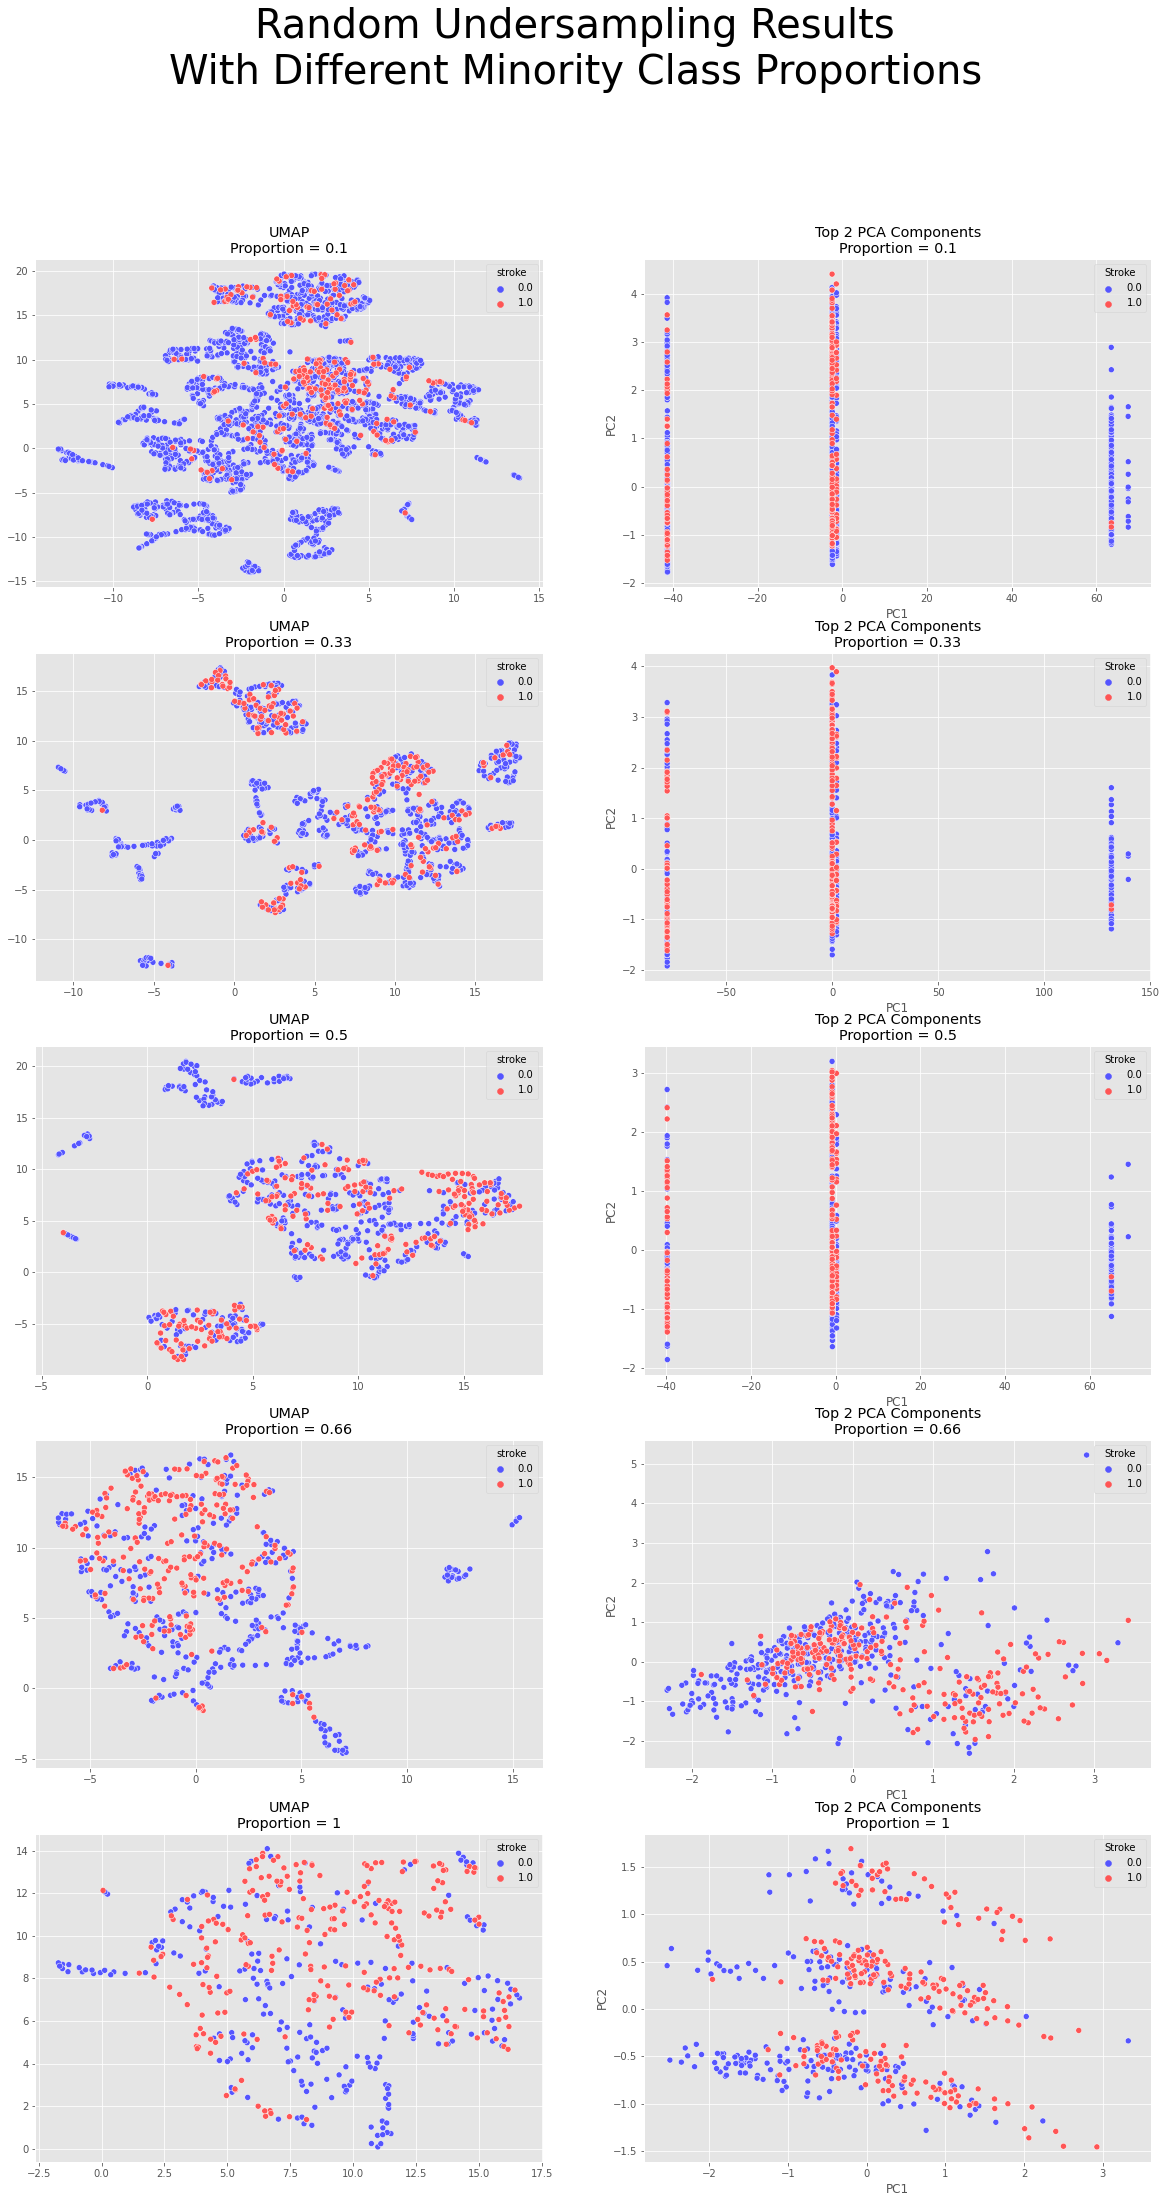

In [28]:
fig,axes=plt.subplots(nrows=5,ncols=2,figsize=(20,35))
fig.suptitle("Random Undersampling Results\nWith Different Minority Class Proportions",fontsize=40)
for i in range(5):
    proportion = proportions[i]
    x_rus, y_rus = undersampled_data[proportion]
    rus_umap = ump.fit_transform(x_rus)
    sns.scatterplot(x=rus_umap[:,0],y=rus_umap[:,1],hue=y_rus,palette="seismic",ax=axes[i,0])
    axes[i,0].set_title(f"UMAP\nProportion = {proportion}")
    pca_rus=pca.fit_transform(x_rus)
    pca_rus=pd.DataFrame(pca_rus,columns=["PC1","PC2"])
    pca_rus["Stroke"]=y_rus
    sns.scatterplot(x="PC1",y="PC2",hue="Stroke",data=pca_rus, palette="seismic",ax=axes[i,1])
    axes[i,1].set_title(f"Top 2 PCA Components\nProportion = {proportion}")
plt.show()

### Model Evaluation with Random Undersampling

In [29]:
for i in range(5):
    proportion = proportions[i]
    x_rus, y_rus = undersampled_data[proportion]
    rf.fit(x_rus,y_rus)
    y_pred_ts=rf.predict(x)
    test_mat_ros=classification_report(y,y_pred_ts)
    print("Random Forest Results with Random Undersampling:")
    print("Proportion = {}\n{}\n\n".format(proportion,test_mat_ros))

Random Forest Results with Random Undersampling:
Proportion = 0.1
              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94      4860
         1.0       0.15      0.24      0.18       249

    accuracy                           0.89      5109
   macro avg       0.55      0.58      0.56      5109
weighted avg       0.92      0.89      0.91      5109



Random Forest Results with Random Undersampling:
Proportion = 0.33
              precision    recall  f1-score   support

         0.0       1.00      0.00      0.01      4860
         1.0       0.05      1.00      0.09       249

    accuracy                           0.05      5109
   macro avg       0.52      0.50      0.05      5109
weighted avg       0.95      0.05      0.01      5109



Random Forest Results with Random Undersampling:
Proportion = 0.5
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      4860
         1.0       0.05      1.00 

### Question: Would other resampling techniques give better results?

My guess is: **probably not**. At least not considerably, and at least not with this data.  
I say this because the minority-class samples are sparsely distributed throughout the majority-class distribution ie **the two classes are not well distinguished/separated**.   

I actually went on and further experimented with SMOTE and as expected; no improvement.

**"What to do now?" I hear you ask, curious viewer.**  
Well, we just try to separate them.  
With some ***Feature Engineering***  .    
**Adding** more informative **features** (ones that reduce entropy in the target feature) would probably separate the two classes, at least a bit more.  
This can be found in the next episode here: https://www.kaggle.com/mahmoudlimam/stroke-pca-ica-lda-kmeans-dbscan-prediction  
Make sure you see it, it's the last episode xD

الحمد لله الذي بنعمته تتم الصالحات